# Библиотеки

In [1]:
import numpy as np
import pandas as pd

import random
import glob
import os, shutil
from tqdm import tqdm
tqdm.pandas()
import time
import copy
import joblib
from collections import defaultdict
import gc
from IPython import display as ipd

# visualization
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Sklearn
from sklearn.model_selection import StratifiedKFold, KFold, StratifiedGroupKFold
from sklearn.model_selection import train_test_split

# PyTorch 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
from torch.cuda import amp

import timm

# Albumentations for augmentations
import albumentations as A
from albumentations.pytorch import ToTensorV2

from joblib import Parallel, delayed

# For colored terminal text
from colorama import Fore, Back, Style
c_  = Fore.GREEN
sr_ = Style.RESET_ALL

import warnings
warnings.filterwarnings("ignore")

# For descriptive error messages
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

import sys
import h5py
from sklearn.preprocessing import StandardScaler

#Модели машинного обучения
import segmentation_models_pytorch as smp

#Утилиты для работы с GPU
import GPUtil

C:\Users\12345654321\anaconda3\Lib\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.5' (you have '2.0.3'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


# Загрузка данных

In [3]:
#Преобразует tif файлы в массив масок и снимков
def load_tif(x_path, y_path,count_dict, step=4):
    images = []
    masks = []
    image = Image.open(x_path)
    mask = Image.open(y_path)
    i = 0
    cnt = 0    

    while True:
        try:
            mask.seek(i)
            mask_array = np.array(mask)
            image.seek(i)
            image_array = np.array(image)
            if sum(sum(mask_array)) > 0: #Проверка, что маска не полностью черная

                #Если маска не из 0 и 1, а из, например, 0 и 255, меняем 255 на 1.
                mask_array[mask_array > 1] = 1
                
                masks.append(mask_array)
                images.append(image_array)
            cnt+=1                    

            i += 1
        except EOFError:
            break

    if 'T1' in x_path:
        count_dict['scan'].append('T1')
    elif 'T2' in x_path:
        count_dict['scan'].append('T2')     
    count_dict['count'].append(cnt) 

    return images, masks

In [4]:
#Достаем изображения и маски из многослойного tif файла
def get_images(x_pathes, y_pathes):

    images =[]
    masks = []
    count_dict = {'scan':[],'count':[],}
    for x_path, y_path in zip(x_pathes, y_pathes):
          
        images_sample,mask_sample = load_tif(x_path, y_path,count_dict)
        for im,ms in zip(images_sample,mask_sample):
                    
            images.append(im)
            masks.append(ms)
              
    print(len(count_dict['count']))

    return images, masks ,count_dict

In [5]:
#Обходит директорию и сохранятет пути пациентов, вычленяет проекции Cor T1 и Cor T2 и маски
def get_pathes(path): 
    x_pathes_all = []
    y_pathes_all = []
    for patient in os.listdir(path):
        x_pathes = []
        y_pathes = []
      
        for ID_s in os.listdir(path + '/'+ patient ):
            if 'ID' in ID_s:
                msk_t1 = 0
                msk_t2 = 0  
                for tif_name in os.listdir(path + '/'+ patient + '/'+ID_s):
    
                    if 'Cor' in tif_name:
                        if 'T1' in tif_name:
            
                            if  'mask' not in tif_name.lower():
                                x_pathes.append(path + '/'+ patient + '/' + ID_s + '/'+ tif_name)

                            elif 'mask' in tif_name.lower():
                                msk_t1 = 1
                                y_pathes.append(path + '/'+ patient + '/'+ID_s + '/' + tif_name)

                        elif 'T2' in tif_name:
                            
                            if 'mask' not in tif_name.lower():
                                x_pathes.append(path + '/'+ patient + '/'+ID_s + '/' + tif_name)
                              
                            elif 'mask' in tif_name.lower():
                                msk_t2 = 1
                                y_pathes.append(path + '/'+ patient + '/'+ID_s + '/' + tif_name)
                        
                if msk_t1==0:
                    x_pathes.pop()
                if msk_t2==0:
                    x_pathes.pop()
                        
        x_pathes_all.append(x_pathes)
        y_pathes_all.append(y_pathes)
                                
    return x_pathes_all, y_pathes_all

In [6]:
def flatten(xss): # для развертки и однородности списков 

    return [x for xs in xss for x in xs]

In [12]:
#Указываем путь до папки с данными. Формат данных - как формирует скрипт загрузки датасета

#Примеры пути для разных сред

#При хранении на Google Drive при работе с Google Colab (в данном примере - данные не сжаты в .zip архиве)
#from google.colab import drive
#drive.mount('/content/drive')
#x_pth, y_pth = get_pathes('/content/drive/MyDrive/data_pituitary_test_light')

#Формат ссылки при хранении на Kaggle
# x_pth, y_pth = get_pathes('/kaggle/input/med-test-light/data_pituitary_test_light')

#Формат ссылки, при хранении на локальном компьютере
x_pth, y_pth = get_pathes('C:/Users/12345654321/data_pituitary_18_01_25')

In [14]:
#Разбиваем данные на train и validation, при желании можно поменять test_size.

x_pth_train,x_pth_val,y_pth_train,y_pth_val = train_test_split(x_pth , y_pth, test_size=0.14)

x_pth_train,y_pth_train,x_pth_val,y_pth_val = flatten(x_pth_train) ,flatten(y_pth_train),flatten(x_pth_val),flatten(y_pth_val)

In [16]:
#Достает изображения и маски, преобразуя в массивы. 

#Первая цифра output - кол-во tif файлов в test датасете (по 2 файла (Cor T1 и Cor T2) на пациента, не включая маски)
#Вторая цифра output - кол-во tif файлов в train датасете (по 2 файла (Cor T1 и Cor T2) на пациента, не включая маски)

x_val,y_val,_ = get_images(x_pth_val ,y_pth_val) 

x_train,y_train,_= get_images(x_pth_train ,y_pth_train)

86
514


# Преобразование данных

In [19]:
class BuildDataset(torch.utils.data.Dataset): # загружает в оперативную память
    
    def __init__(self, X,y, label=True, transforms=None):
        self.label      = label
        self.img_paths  = X
        self.msk_paths  = y
        self.transforms = transforms
        
    def __len__(self):

        return len(self.img_paths)
    
    def __getitem__(self, index):

        if self.label == True:

            img = self.img_paths[index]
            msk = self.msk_paths[index]

            if self.transforms:

                data = self.transforms(image=np.array(img/255., dtype=np.float32)  , mask=np.array(msk, dtype=np.float32))
                img  = data['image']
                msk  = data['mask']

            return torch.tensor([img]), torch.tensor([msk])

        else:

            img = self.img_paths[index]
            if self.transforms:
                data = self.transforms(image=np.array(img/255., dtype=np.float32))
                img  = data['image']
            return torch.tensor([img])

In [21]:
data_transforms = {
    "train": A.Compose([
        A.Resize(512,512, interpolation=cv2.INTER_NEAREST),
        A.augmentations.crops.transforms.CenterCrop(256,256),
        A.Resize(224,224, interpolation=cv2.INTER_NEAREST),
        A.CoarseDropout(max_holes=8, max_height=224//20, max_width=224//20,
                         min_holes=5, fill_value=0, mask_fill_value=0, p=0.5),
        

        A.HorizontalFlip(p=0.5),
#         A.VerticalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.05, rotate_limit=10, p=0.5),
        A.OneOf([
            A.GridDistortion(num_steps=5, distort_limit=0.05, p=1.0),
            # A.OpticalDistortion(distort_limit=0.05, shift_limit=0.05, p=1.0),
            A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=1.0)
        ], p=0.25),
        # A.ColorJitter(brightness=0, contrast=0.0002, saturation=0, hue=0.2, always_apply=False, p=0.5),
        # A.CoarseDropout(max_holes=8, max_height=224//20, max_width=224//20,
        #                  min_holes=5, fill_value=0, mask_fill_value=0, p=0.5),
        A.augmentations.Normalize(mean=(0.485, ), std=(0.229, )),
        ], p=1.0),
    
    "valid": A.Compose([
        A.Resize(512,512, interpolation=cv2.INTER_NEAREST),
        A.augmentations.crops.transforms.CenterCrop(256,256),
        A.Resize(224,224, interpolation=cv2.INTER_NEAREST),
        A.augmentations.Normalize(mean=(0.485, ), std=(0.229, )),
        ], p=1.0)
}

In [23]:
train_dataset = BuildDataset(x_train,y_train, transforms=data_transforms['train'])
valid_dataset = BuildDataset(x_val,y_val, transforms=data_transforms['valid'])

train_batch_size = 32
valid_batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=valid_batch_size, shuffle=False)

Проверка

In [26]:
def plot_batch(imgs, msks, size=3):
    plt.figure(figsize=(5*5, 5))
    for idx in range(size):
        plt.subplot(1, size, idx+1)
        img = imgs[idx,].permute((1, 2, 0)).numpy()*255.0 
        msk = msks[idx,].permute((1, 2, 0)).numpy()
        show_img(img, msk)
    plt.tight_layout()
    plt.show()

In [28]:
def show_img(img, mask=None):

    plt.imshow(img, cmap='bone')        

    plt.imshow(mask, alpha=0.5)
    handles = [Rectangle((0,0),1,1, color=_c) for _c in [(0.667,0.0,0.0)]]
    labels = ["Adenoma"]
    plt.legend(handles,labels)
    plt.axis('off')

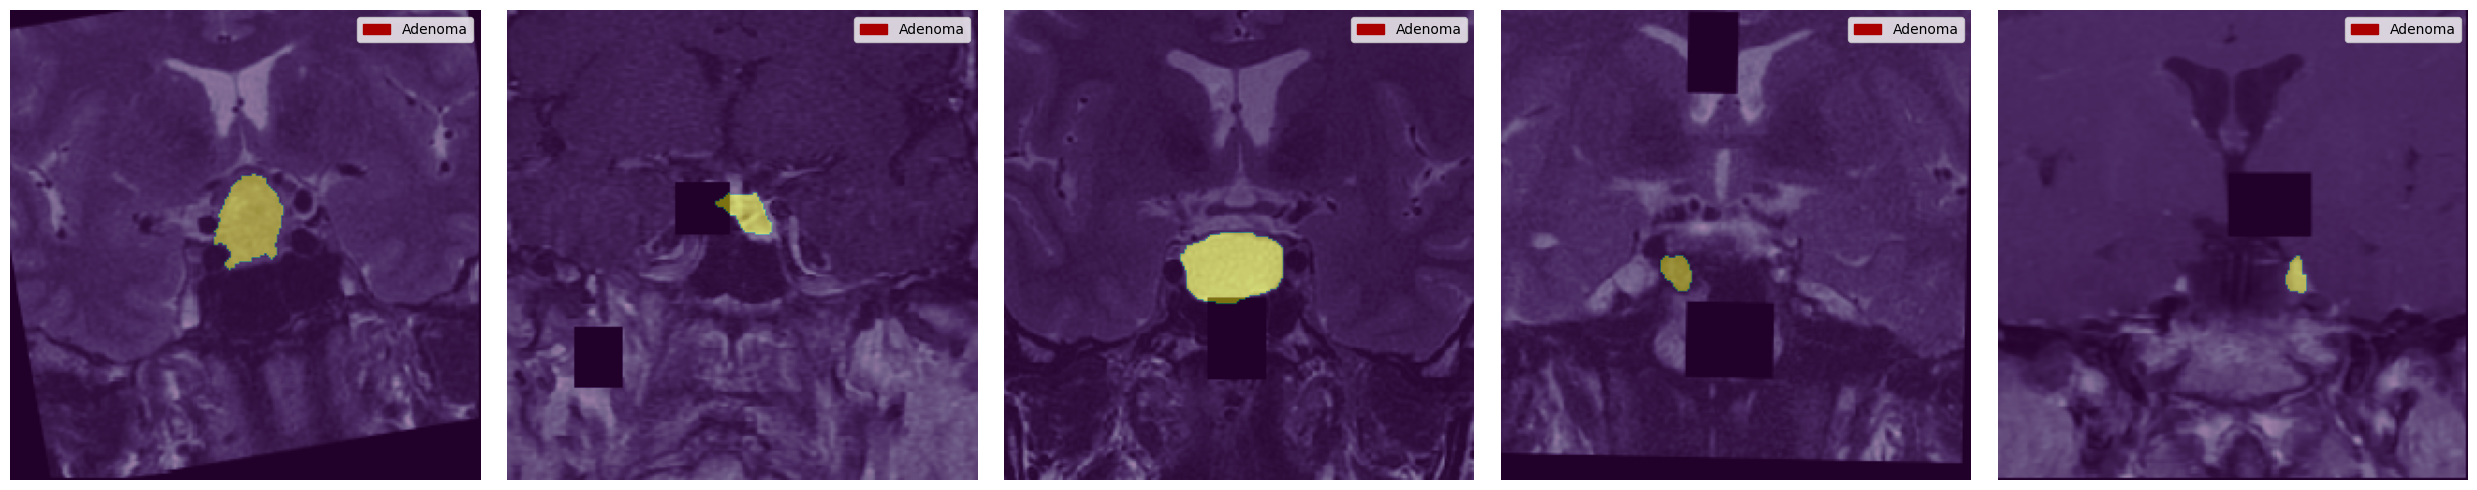

In [30]:
#Изображение после train преобразования + маска.

imgs, msks = next(iter(train_loader))
plot_batch(imgs, msks, size=5)

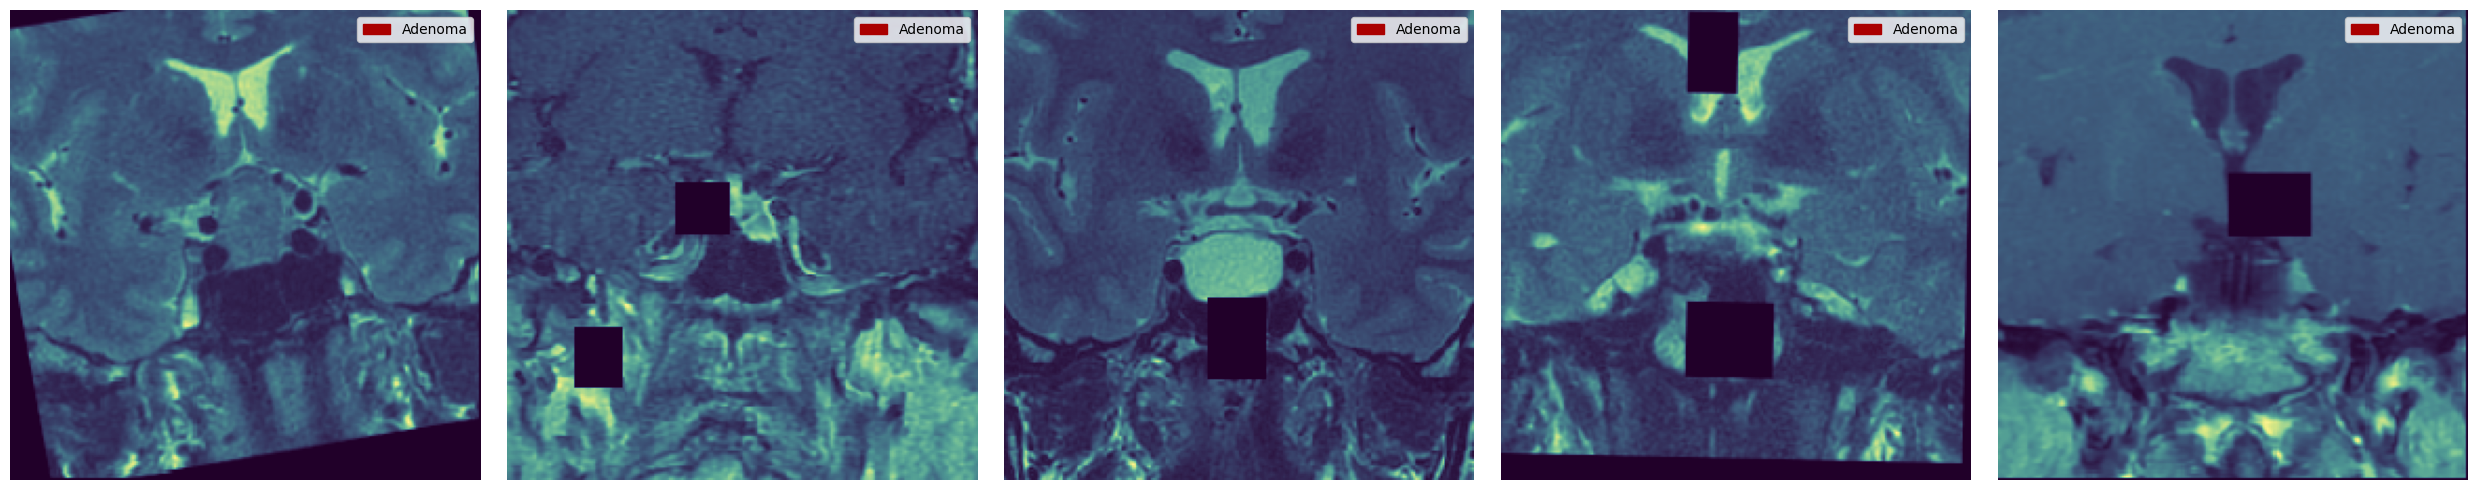

In [32]:
#Изображение после train преобразования

plot_batch(imgs, imgs, size=5)

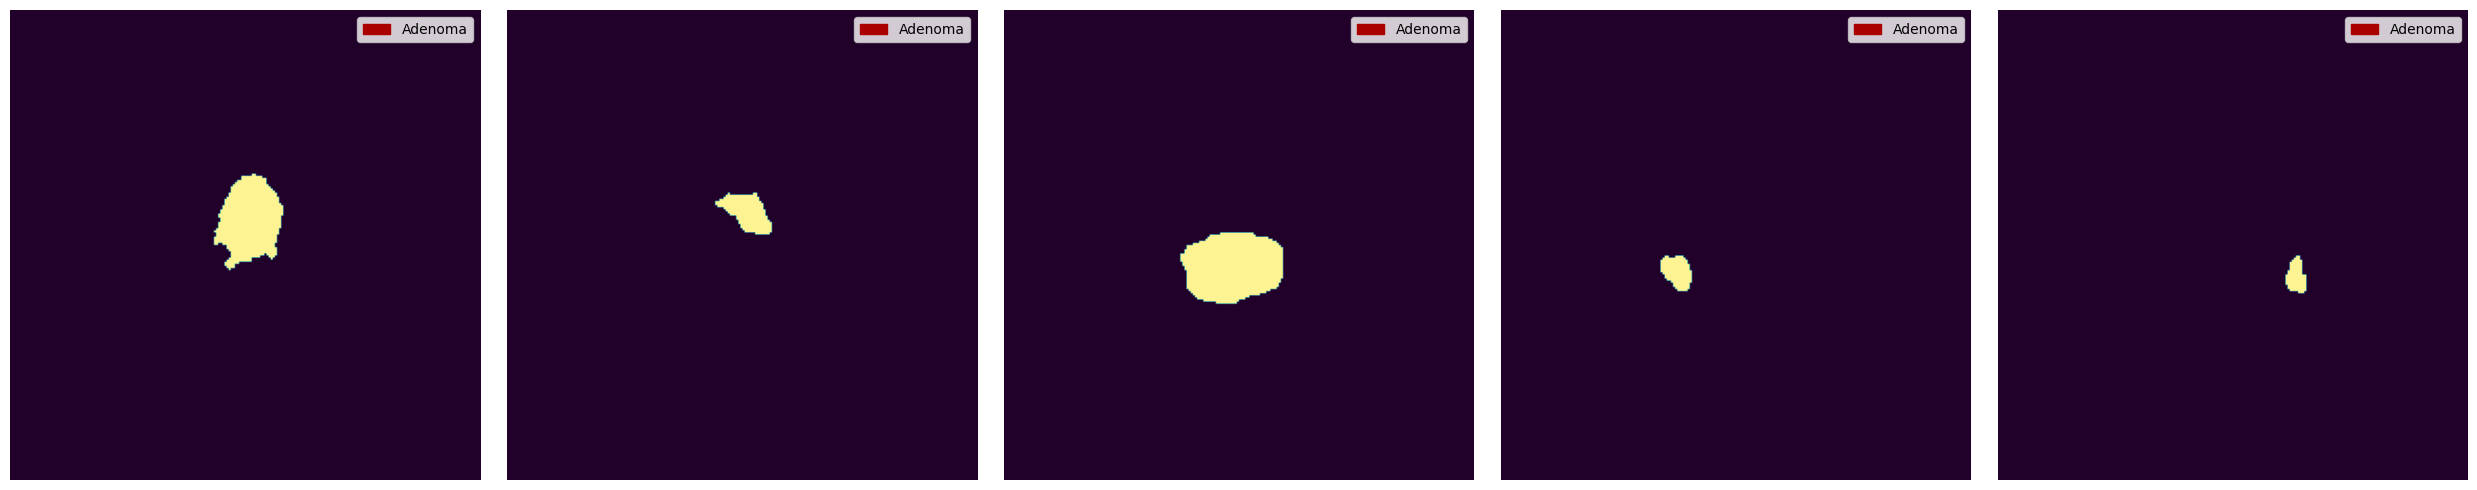

In [34]:
#Маска

plot_batch(msks, msks, size=5)

# Модель

In [37]:
#Принудительно включаем garbage collector (чтобы улучшить производительность обучения)

gc.collect()

9760

In [39]:
def build_model():
    model = smp.UnetPlusPlus(
        encoder_name='efficientnet-b1' ,
                  # choose encoder, e.g. mobilenet_v2 or efficientnet-b7
        encoder_weights='imagenet',# use `imagenet` pre-trained weights for encoder initialization
        in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
        classes=1   ,     # model output channels (number of classes in your dataset)
        activation=None,
    )
    model.to('cuda')
    return model

def load_model(path):
    model = build_model()
    model.load_state_dict(torch.load(path))
    model.eval()
    return model

# Loss

In [42]:
JaccardLoss = smp.losses.JaccardLoss(mode='binary')
DiceLoss    = smp.losses.DiceLoss(mode='binary')
BCELoss     = smp.losses.SoftBCEWithLogitsLoss()
LovaszLoss  = smp.losses.LovaszLoss(mode='binary', per_image=False)
TverskyLoss = smp.losses.TverskyLoss(mode='binary', log_loss=False)

def dice_coef(y_true, y_pred, thr=0.5, dim=(2,3), epsilon=0.001):
    y_true = y_true.to(torch.float32)
    y_pred = (y_pred>thr).to(torch.float32)
    inter = (y_true*y_pred).sum(dim=dim)
    den = y_true.sum(dim=dim) + y_pred.sum(dim=dim)
    dice = ((2*inter+epsilon)/(den+epsilon)).mean(dim=(1,0))
    return dice

def iou_coef(y_true, y_pred, thr=0.5, dim=(2,3), epsilon=0.001):
    y_true = y_true.to(torch.float32)
    y_pred = (y_pred>thr).to(torch.float32)
    inter = (y_true*y_pred).sum(dim=dim)
    union = (y_true + y_pred - y_true*y_pred).sum(dim=dim)
    iou = ((inter+epsilon)/(union+epsilon)).mean(dim=(1,0))
    return iou

def criterion(y_pred, y_true):
    return BCELoss(y_pred, y_true) + TverskyLoss(y_pred, y_true)

# Обучение

In [45]:
#Обучение одной эпохи

def train_one_epoch(model, optimizer, scheduler, dataloader, device, epoch):
    model.train()
    scaler = amp.GradScaler()
    train_scores = []
    dataset_size = 0
    running_loss = 0.0
    
    pbar = tqdm(enumerate(dataloader), total=len(dataloader), desc='Train ')
    for step, (images, masks) in pbar:         
        images = images.to(device, dtype=torch.float)
        masks  = masks.to(device, dtype=torch.float)
        
        batch_size = images.size(0)
        
        with amp.autocast(enabled=True):
            y_pred = model(images)
            
            loss   = criterion(y_pred, masks)
            loss   = loss / CFG.n_accumulate
            
        scaler.scale(loss).backward()
    
        if (step + 1) % CFG.n_accumulate == 0:
            scaler.step(optimizer)
            scaler.update()

            # zero the parameter gradients
            optimizer.zero_grad()

            if scheduler is not None:
                scheduler.step()
                
        running_loss += (loss.item() * batch_size)
        dataset_size += batch_size
        
        epoch_loss = running_loss / dataset_size

        y_pred = (nn.Sigmoid()(y_pred)).double()
        train_dice = dice_coef(masks, y_pred).cpu().detach().numpy()
        vtrain_jaccard = iou_coef(masks, y_pred).cpu().detach().numpy()
        train_scores.append([train_dice, vtrain_jaccard])
        
        mem = torch.cuda.memory_reserved() / 1E9 if torch.cuda.is_available() else 0
        current_lr = optimizer.param_groups[0]['lr']
        pbar.set_postfix(train_loss=f'{epoch_loss:0.4f}',
                        lr=f'{current_lr:0.5f}',
                        gpu_mem=f'{mem:0.2f} GB')
        
    train_scores  = np.mean(train_scores, axis=0)    
    torch.cuda.empty_cache()
    gc.collect()
    
    return epoch_loss,train_scores

In [47]:
#Валидация одной эпохи

@torch.no_grad()
def valid_one_epoch(model, dataloader, device, epoch):
    model.eval()
    
    dataset_size = 0
    running_loss = 0.0
    
    val_scores = []
    
    pbar = tqdm(enumerate(dataloader), total=len(dataloader), desc='Valid ')
    for step, (images, masks) in pbar:        
        images  = images.to(device, dtype=torch.float)
        masks   = masks.to(device, dtype=torch.float)
        
        batch_size = images.size(0)
        
        y_pred  = model(images)
        loss    = criterion(y_pred, masks)
        
        running_loss += (loss.item() * batch_size)
        dataset_size += batch_size
        
        epoch_loss = running_loss / dataset_size
        
        y_pred = (nn.Sigmoid()(y_pred)).double()
        val_dice = dice_coef(masks, y_pred).cpu().detach().numpy()
        val_jaccard = iou_coef(masks, y_pred).cpu().detach().numpy()
        val_scores.append([val_dice, val_jaccard])
        
        mem = torch.cuda.memory_reserved() / 1E9 if torch.cuda.is_available() else 0
        current_lr = optimizer.param_groups[0]['lr']
        pbar.set_postfix(valid_loss=f'{epoch_loss:0.4f}',
                        lr=f'{current_lr:0.5f}',
                        gpu_memory=f'{mem:0.2f} GB')
        
        
    val_scores  = np.mean(val_scores, axis=0)
    torch.cuda.empty_cache()
    gc.collect()
    
    return epoch_loss, val_scores

In [49]:
#Процесс обучения

def run_training(model, optimizer, scheduler, device, num_epochs):
    # To automatically log gradients
    # wandb.watch(model, log_freq=100)
    
    if torch.cuda.is_available():
        print("cuda: {}\n".format(torch.cuda.get_device_name()))
    
    start = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_dice      = -np.inf
    best_epoch     = -1
    history = defaultdict(list)
    
    for epoch in range(1, num_epochs + 1): 
        gc.collect()
        print(f'Epoch {epoch}/{num_epochs}', end='')
        train_loss,train_scores = train_one_epoch(model, optimizer, scheduler, 
                                           dataloader=train_loader, 
                                           device=CFG.device, epoch=epoch)
        train_dice,train_jaccard = train_scores

        print(f'Train Dice: {train_dice:0.4f} | Train Jaccard: {train_jaccard:0.4f}')

        val_loss, val_scores = valid_one_epoch(model, valid_loader, 
                                                 device=CFG.device, 
                                                 epoch=epoch)
        val_dice, val_jaccard = val_scores
    
        history['Train Loss'].append(train_loss)
        history['Train Dice'].append(train_dice)
        history['Train Jaccard'].append(train_jaccard)
        history['Valid Loss'].append(val_loss)
        history['Valid Dice'].append(val_dice)
        history['Valid Jaccard'].append(val_jaccard)
        
        # Log the metrics
        # wandb.log({"Train Loss": train_loss, 
        #            "Valid Loss": val_loss,
        #            "Valid Dice": val_dice,
        #            "Valid Jaccard": val_jaccard,
        #            "LR":scheduler.get_last_lr()[0]})
        
        print(f'Valid Dice: {val_dice:0.4f} | Valid Jaccard: {val_jaccard:0.4f}')
        
        # deep copy the model
        if val_dice > best_dice:
            print(f"{c_}Valid Score Improved ({best_dice:0.4f} ---> {val_dice:0.4f})")
            best_dice    = val_dice
            best_jaccard = val_jaccard
            best_epoch   = epoch
            run.summary["Best Dice"]    = best_dice
            run.summary["Best Jaccard"] = best_jaccard
            run.summary["Best Epoch"]   = best_epoch
            best_model_wts = copy.deepcopy(model.state_dict())
            PATH = f"best_epoch-{fold:02d}.bin"
            torch.save(model.state_dict(), PATH)
            # Save a model file from the current directory
            # wandb.save(PATH)
            print(f"Model Saved{sr_}")
            
        last_model_wts = copy.deepcopy(model.state_dict())
        PATH = f"last_epoch-{fold:02d}.bin"
        torch.save(model.state_dict(), PATH)
            
        print(); print()
    
    end = time.time()
    time_elapsed = end - start
    print('Training complete in {:.0f}h {:.0f}m {:.0f}s'.format(
        time_elapsed // 3600, (time_elapsed % 3600) // 60, (time_elapsed % 3600) % 60))
    print("Best Score: {:.4f}".format(best_jaccard))
    
    # load best model weights
    model.load_state_dict(best_model_wts)
    
    return model, history

In [51]:
class CFG:
    seed          = 42
    debug         = False # set debug=False for Full Training
    exp_name      = 'Baselinev2'
    comment       = 'unet-efficientnet_b1-224x224-seg_cor'
    model_name    = 'Unet'
    backbone      = 'efficientnet-b1'
    train_bs      = 128
    valid_bs      = train_bs*2
    img_size      = [224, 224]
    epochs        = 50
    lr            = 1e-4
    scheduler     = 'CosineAnnealingLR'
    min_lr        = 1e-6
    T_max         = int(30000/train_bs*epochs)+50
    T_0           = 25
    warmup_epochs = 0
    wd            = 1e-6
    n_accumulate  = max(1, 32//train_bs)
    n_fold        = 5
    num_classes   = 3
    device        = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [53]:
def fetch_scheduler(optimizer):
    if CFG.scheduler == 'CosineAnnealingLR':
        scheduler = lr_scheduler.CosineAnnealingLR(optimizer,T_max=CFG.T_max, 
                                                   eta_min=CFG.min_lr)
    elif CFG.scheduler == 'CosineAnnealingWarmRestarts':
        scheduler = lr_scheduler.CosineAnnealingWarmRestarts(optimizer,T_0=CFG.T_0, 
                                                             eta_min=CFG.min_lr)
    elif CFG.scheduler == 'ReduceLROnPlateau':
        scheduler = lr_scheduler.ReduceLROnPlateau(optimizer,
                                                   mode='min',
                                                   factor=0.1,
                                                   patience=7,
                                                   threshold=0.0001,
                                                   min_lr=CFG.min_lr,)
    elif CFG.scheduer == 'ExponentialLR':
        scheduler = lr_scheduler.ExponentialLR(optimizer, gamma=0.85)
    elif CFG.scheduler == None:
        return None
        
    return scheduler

In [55]:
model = build_model()
optimizer = optim.Adam(model.parameters(), lr=CFG.lr, weight_decay=CFG.wd)
scheduler = fetch_scheduler(optimizer)

In [57]:
#Здесь предполагается, что у вас в Kaggle в Secrets (во вкладке Add-ons) прописан api-key для Wandb
#В противном случае, он "подключается" к нему (на деле - нет). 

import wandb

try:
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    api_key = user_secrets.get_secret("WANDB")
    wandb.login(key=api_key)
    anonymous = None
except:
    anonymous = "must"
    print('To use your W&B account,\nGo to Add-ons -> Secrets and provide your W&B access token. Use the Label name as WANDB. \nGet your W&B access token from here: https://wandb.ai/authorize')

To use your W&B account,
Go to Add-ons -> Secrets and provide your W&B access token. Use the Label name as WANDB. 
Get your W&B access token from here: https://wandb.ai/authorize


Запуск

###############
### Fold: 0
###############


wandb: Currently logged in as: snik911 (snik911-mephi). Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


cuda: NVIDIA GeForce RTX 3050 Laptop GPU

Epoch 1/50

Train : 100%|██████████| 103/103 [01:58<00:00,  1.15s/it, gpu_mem=4.18 GB, lr=0.00010, train_loss=1.2780]


Train Dice: 0.3561 | Train Jaccard: 0.2558


...

Valid Dice: 0.7193 | Valid Jaccard: 0.6076


Epoch 50/50

Train : 100%|██████████| 103/103 [02:24<00:00,  1.40s/it, gpu_mem=4.25 GB, lr=0.00006, train_loss=0.0834]


Train Dice: 0.8765 | Train Jaccard: 0.8035


Valid : 100%|██████████| 16/16 [00:10<00:00,  1.59it/s, gpu_memory=2.16 GB, lr=0.00006, valid_loss=0.2522]


Valid Dice: 0.7271 | Valid Jaccard: 0.6159


Training complete in 2h 9m 50s
Best Score: 0.6183


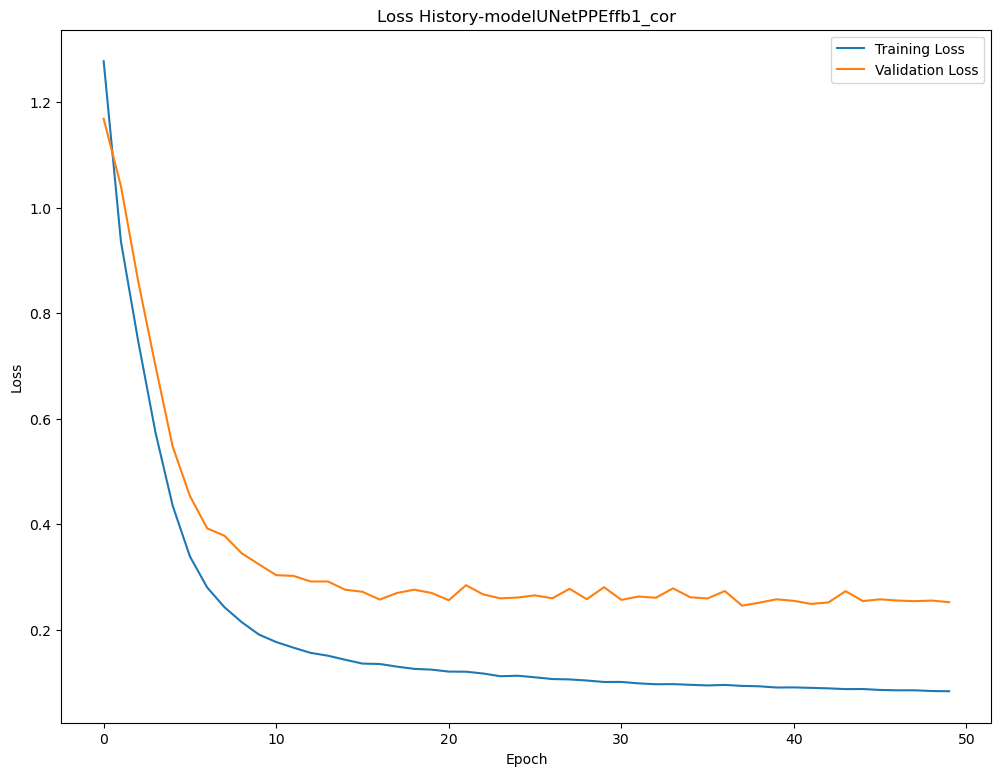

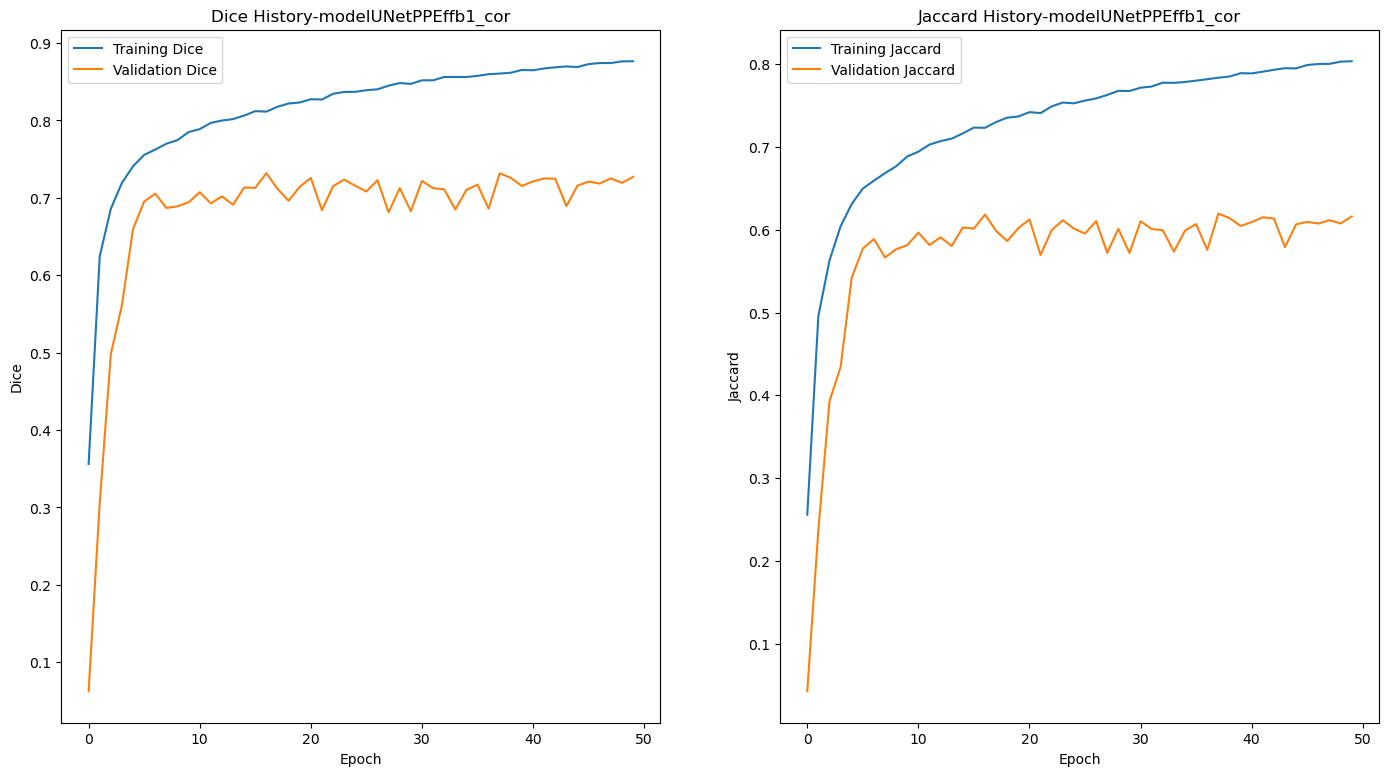

In [60]:
for fold in range(1):
    seg_model_name = 'UNetPPEffb1_cor'
    print(f'#'*15)
    print(f'### Fold: {fold}')
    print(f'#'*15)
    run = wandb.init(project='med-segmentation-unetppb1-cor', 
                     config={k:v for k, v in dict(vars(CFG)).items() if '__' not in k},
                     anonymous=anonymous,
                     name=f"fold-{fold}|dim-{CFG.img_size[0]}x{CFG.img_size[1]}|model-{CFG.model_name}",
                     group=CFG.comment,
                    )
    train_loader, valid_loader = train_loader,valid_loader
    model     =   build_model()
    optimizer = optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.wd)
    scheduler =  fetch_scheduler(optimizer) 
    
    model, historys_UNET = run_training(model, optimizer, scheduler,
                                device=CFG.device,
                                num_epochs=CFG.epochs)
    # run.finish()
    # display(ipd.IFrame(run.url, width=1000, height=720))
    plt.figure(figsize=(12,9))

    plt.plot(historys_UNET['Train Loss'], label=f'Training Loss')
    plt.plot(historys_UNET['Valid Loss'], label=f'Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'Loss History-model{seg_model_name}')


    plt.figure(figsize=(17,9))
    plt.subplot(1, 2, 1)
    plt.plot(historys_UNET['Train Dice'], label=f'Training Dice')
    plt.plot(historys_UNET['Valid Dice'], label=f'Validation Dice')
    plt.xlabel('Epoch')
    plt.ylabel('Dice')
    plt.legend()
    plt.title(f'Dice History-model{seg_model_name}')

    plt.subplot(1, 2, 2)
    plt.plot(historys_UNET['Train Jaccard'], label=f'Training Jaccard')
    plt.plot(historys_UNET['Valid Jaccard'], label=f'Validation Jaccard')
    plt.xlabel('Epoch')
    plt.ylabel('Jaccard')
    plt.legend()
    plt.title(f'Jaccard History-model{seg_model_name}')
    plt.show()
    torch.save(model.state_dict(), f'{seg_model_name}_std.pth')
    torch.save(model, f'{seg_model_name}.pt')

In [62]:
history = historys_UNET
print(f""" MODEL: {seg_model_name} Train DICE MAX:{max(history['Train Dice'])} IOU MAX:{max(history['Train Jaccard'])} Train Loss MIN:{min(history['Train Loss'])} 
        MODEL: {seg_model_name} VAL DICE MAX:{max(history['Valid Dice'])} VAL IOU MAX:{max(history['Valid Jaccard'])} VAL Loss MIN:{min(history['Valid Loss'])} \n """)

 MODEL: UNetPPEffb1_cor Train DICE MAX:0.8765079379081726 IOU MAX:0.8034693002700806 Train Loss MIN:0.08344749214440367 
        MODEL: UNetPPEffb1_cor VAL DICE MAX:0.7318520545959473 VAL IOU MAX:0.6194047927856445 VAL Loss MIN:0.24572479898780883 
 


In [64]:
gpus = GPUtil.getGPUs()
GPUtil.showUtilization()
for i in range(len(gpus)):
    gpu = gpus[i]
    free_memory = gpu.memoryFree
torch.cuda.empty_cache()

| ID | GPU | MEM |
------------------
|  0 |  0% |  8% |


# Валидация

In [67]:
gpus = GPUtil.getGPUs()
GPUtil.showUtilization()
for i in range(len(gpus)):
    gpu = gpus[i]
    free_memory = gpu.memoryFree
torch.cuda.empty_cache()

| ID | GPU | MEM |
------------------
|  0 |  0% |  6% |


In [69]:
valid_dataset = BuildDataset(x_val, y_val, transforms=data_transforms['valid'])
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False, pin_memory=True)

In [71]:
weight_c1 = 'UNetPPEffb1_cor_std.pth'
model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b1", encoder_weights=None, in_channels=1, classes=1)
model.to('cuda')
model.load_state_dict(torch.load(
    weight_c1, map_location='cuda'))
model.eval()

UnetPlusPlus(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      1, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_depthwise_conv): Conv2dStaticSamePadding(
          32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          32, 8, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          8, 32, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_project_conv): Conv2dStaticSam

In [73]:
device='cpu'

In [75]:
preds = []
for step, (images, masks) in enumerate(valid_loader):        
        images  = images.to(device, dtype=torch.float).cpu()
        masks   = masks.to(device, dtype=torch.float).cpu()
        models=model.cpu()

        for fold in range(1):
            # model = load_model(f"best_epoch-{fold:02d}.bin")
            with torch.no_grad():
                pred = models(images).cpu()
                pred = (nn.Sigmoid()(pred)>0.5).double()
                
                #preds = torch.argmax(nn.Sigmoid()(pred),axis=1).double()
                #val_dice = dice_coef(mask, pred).cpu().detach().numpy()
                #val_jaccard = iou_coef(mask, pred).cpu().detach().numpy()
                #val_scores.append([val_dice, val_jaccard])
                
                
                print( sum(sum(sum(sum(pred)))))
            preds.append(pred)
            
        images  = images.cpu().detach()
        preds = torch.mean(torch.stack(preds, dim=0), dim=0).cpu().detach()
        break

tensor(45436., dtype=torch.float64)


In [76]:
#Метрика Dice-Sørensen coefficient

dice_coef(masks, preds).cpu().detach().numpy()

array(0.69431627, dtype=float32)

In [79]:
#Метрика IoU (Jaccard index)

iou_coef(masks, preds).cpu().detach().numpy()

array(0.5708931, dtype=float32)

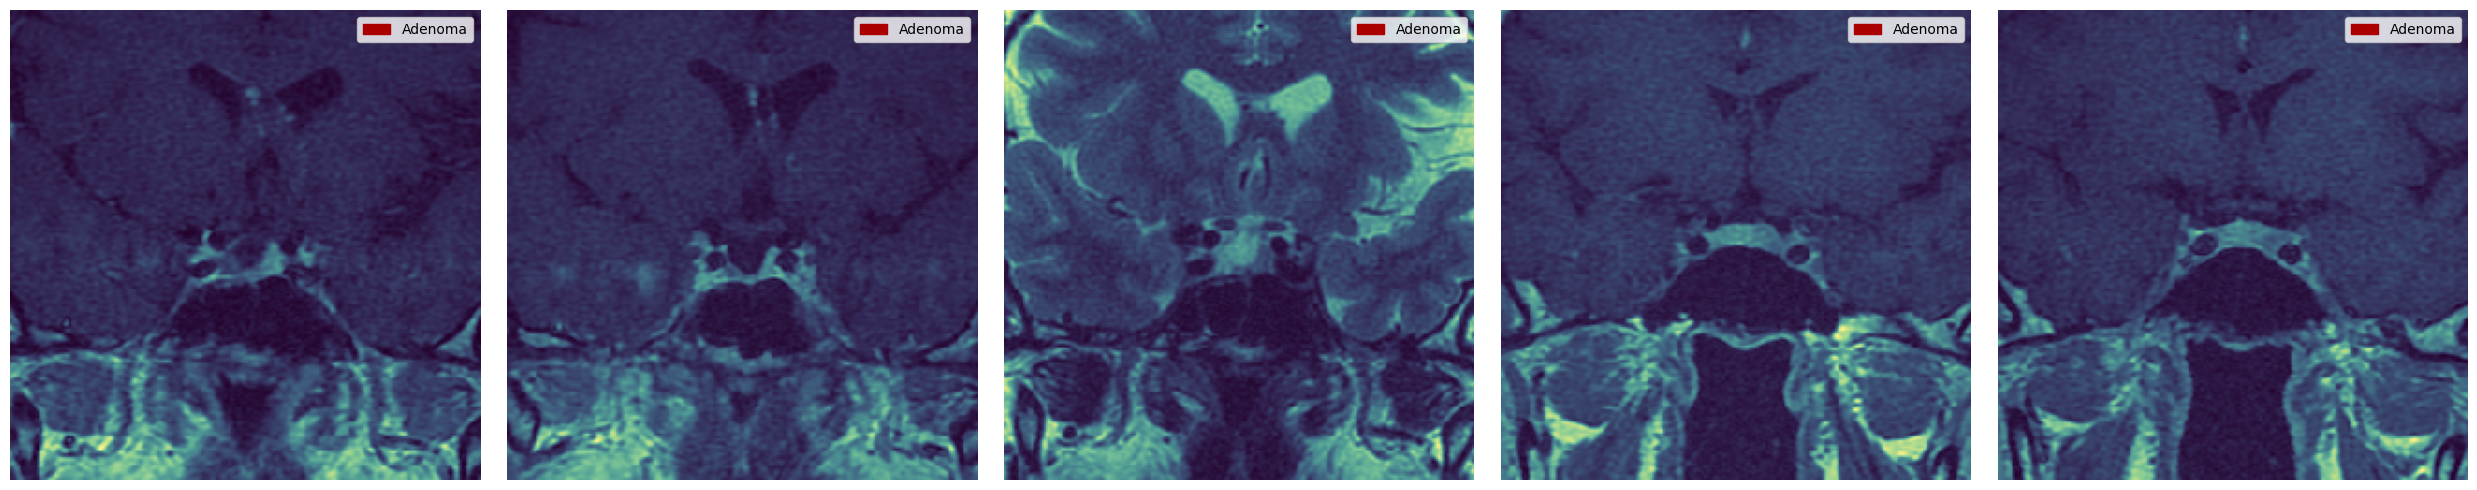

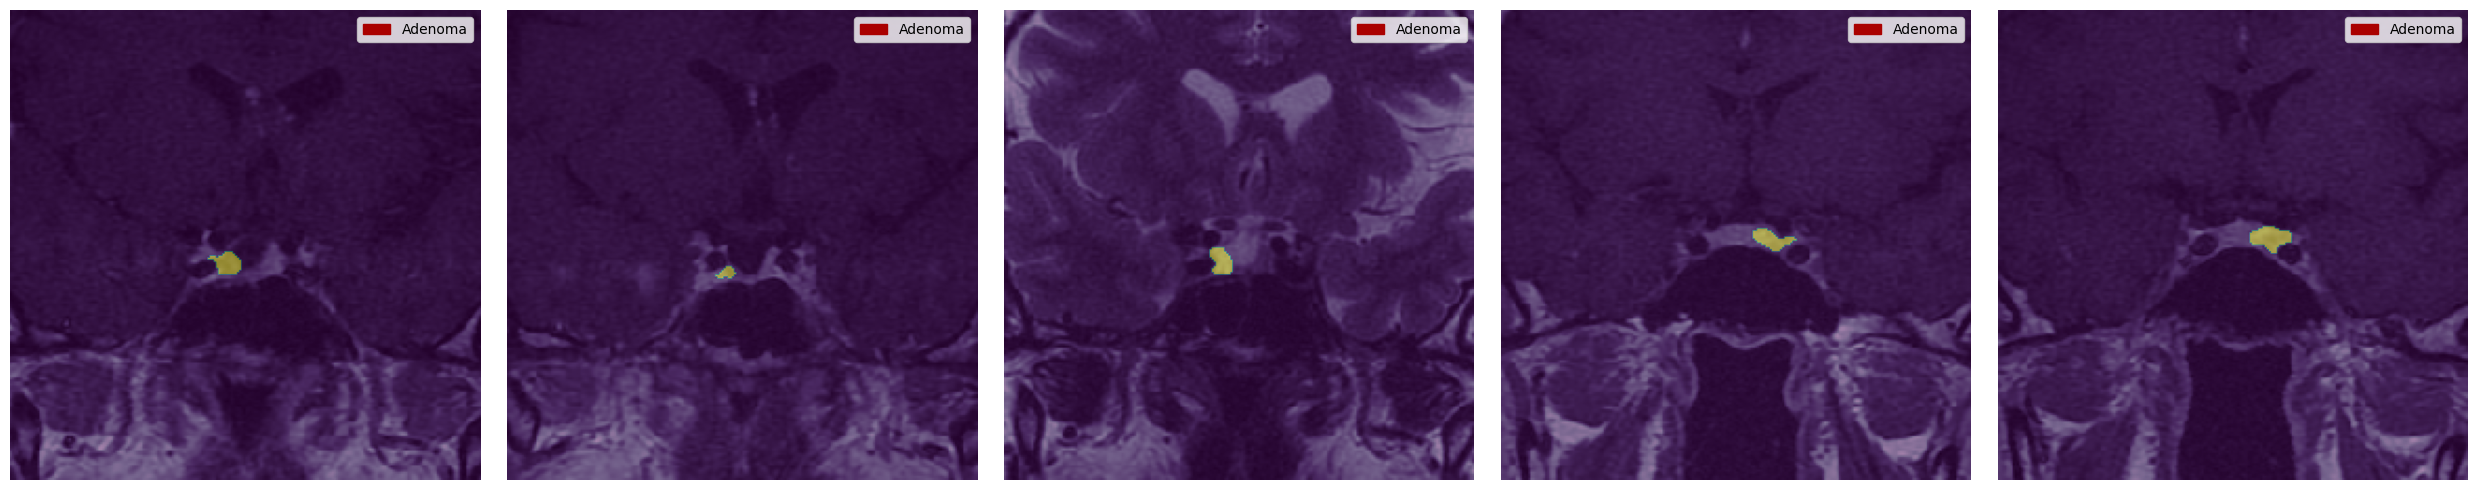

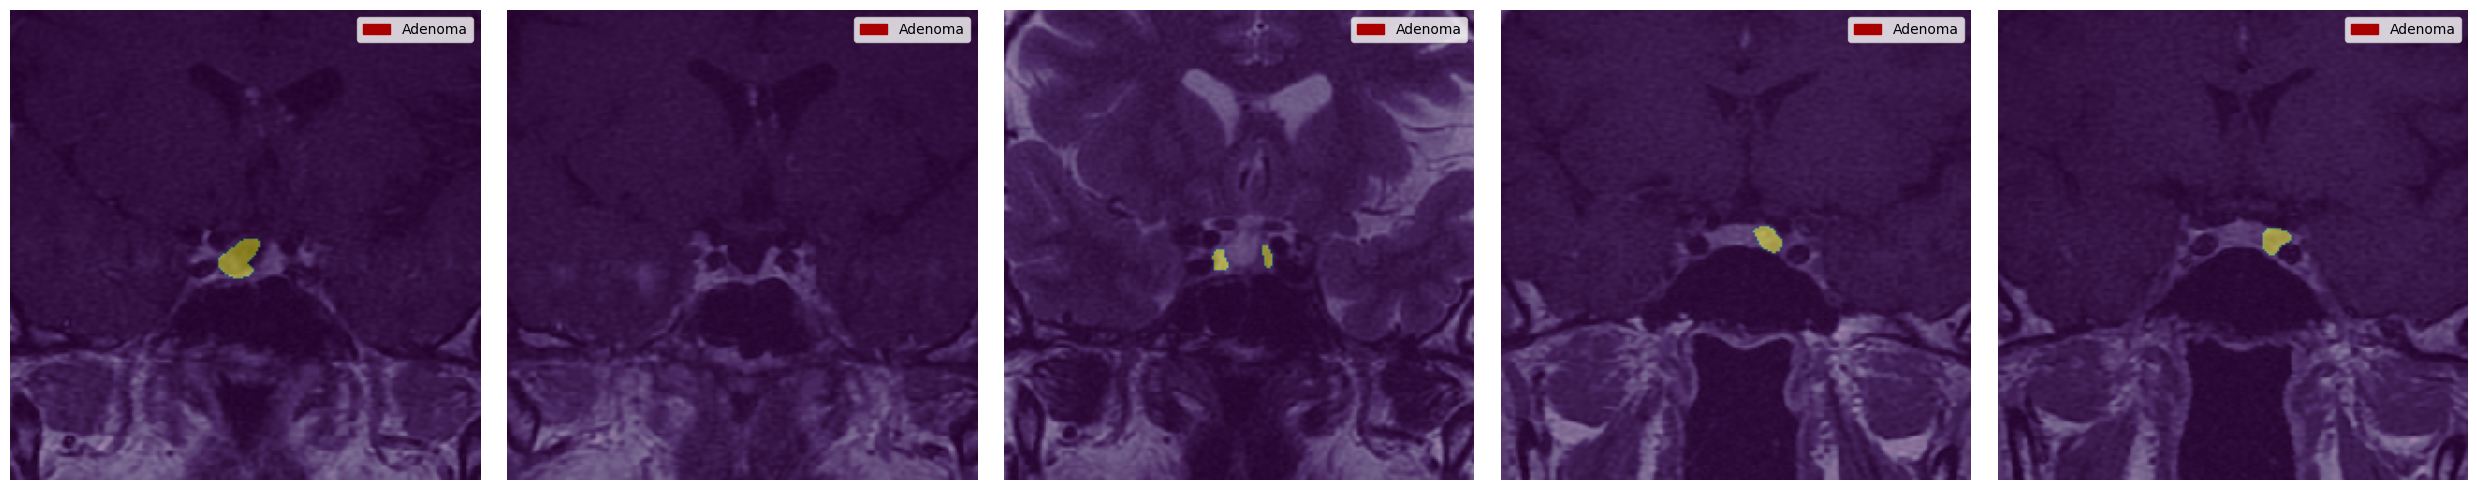

In [81]:
# Изображение результатов

plot_batch(images, images, size=5)
plot_batch(images, masks, size=5)
plot_batch(images, preds, size=5)